# 📊 Exploratory Data Analysis — Early Warning System
**Objectif :** Comprendre la distribution des données, identifier les variables clés et valider les choix du modèle de Régression Logistique.

**Dataset :** `data.csv` — 4 050 étudiants · 14 features · 1 cible (`pass`)

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Style global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
COLORS = {'PASS': '#2ecc71', 'FAIL': '#e74c3c', 'neutral': '#3498db'}

DATA_PATH = 'data.csv'

## 1. Chargement & Aperçu général

In [2]:
df = pd.read_csv(DATA_PATH, sep=';')
df.columns = df.columns.str.strip()

print(f"Dimensions  : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Mémoire     : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head()

Dimensions  : 4,050 lignes × 15 colonnes
Mémoire     : 474.7 KB


,student_id,attendance_pct,absence_hours,homework_pct,study_hours_per_week,midterm_score,informatique,mathematique,svt,physique,sport,education_islamique,francais,arabe,pass
0,1,95.0,5,92.0,12,88.0,88.4,82.4,90.5,95.4,78.7,78.2,95.4,94.9,1
1,2,88.0,27,85.0,10,79.0,96.9,88.2,86.3,93.6,53.2,53.5,84.1,76.2,1
2,3,60.0,67,55.0,4,58.0,54.0,53.1,79.2,61.0,64.4,31.7,56.0,64.7,0
3,4,72.0,42,70.0,6,65.0,65.7,57.8,58.8,56.6,97.0,61.7,48.2,74.3,1
4,5,40.0,103,45.0,3,50.0,53.6,37.8,36.9,53.3,66.3,55.3,50.0,47.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4050 entries, 0 to 4049
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            4050 non-null   int64  
 1   attendance_pct        4050 non-null   float64
 2   absence_hours         4050 non-null   int64  
 3   homework_pct          4050 non-null   float64
 4   study_hours_per_week  4050 non-null   int64  
 5   midterm_score         4050 non-null   float64
 6   informatique          4050 non-null   float64
 7   mathematique          4050 non-null   float64
 8   svt                   4050 non-null   float64
 9   physique              4050 non-null   float64
 10  sport                 4050 non-null   float64
 11  education_islamique   4050 non-null   float64
 12  francais              4050 non-null   float64
 13  arabe                 4050 non-null   float64
 14  pass                  4050 non-null   int64  
dtypes: float64(11), int64

In [4]:
# Valeurs manquantes
missing = df.isnull().sum()
print("Valeurs manquantes par colonne :")
print(missing[missing > 0] if missing.any() else "✅ Aucune valeur manquante")

Valeurs manquantes par colonne :
✅ Aucune valeur manquante


In [5]:
# Statistiques descriptives
df.drop(columns='student_id').describe().T.style.background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max
attendance_pct,4050.000000,70.590296,20.144144,15.000000,52.800000,77.200000,86.100000,100.000000
absence_hours,4050.000000,59.462963,42.581884,0.000000,26.000000,49.000000,93.750000,180.000000
homework_pct,4050.000000,65.911951,20.952898,12.000000,50.800000,68.650000,82.275000,100.000000
study_hours_per_week,4050.000000,7.282963,3.696825,1.000000,4.000000,8.000000,10.000000,19.000000
midterm_score,4050.000000,63.106074,18.770479,15.000000,45.700000,68.300000,78.200000,99.000000
informatique,4050.000000,63.284642,21.691111,10.000000,46.300000,66.250000,80.900000,100.000000
mathematique,4050.000000,63.567679,20.719312,10.000000,47.300000,67.000000,79.600000,100.000000
svt,4050.000000,63.083086,21.852249,10.000000,46.100000,65.800000,79.975000,100.000000
physique,4050.000000,63.493951,21.454225,10.000000,46.200000,66.550000,80.000000,100.000000
sport,4050.000000,62.327506,23.831905,10.000000,45.225000,63.600000,80.800000,100.000000


## 2. Distribution de la variable cible `pass`

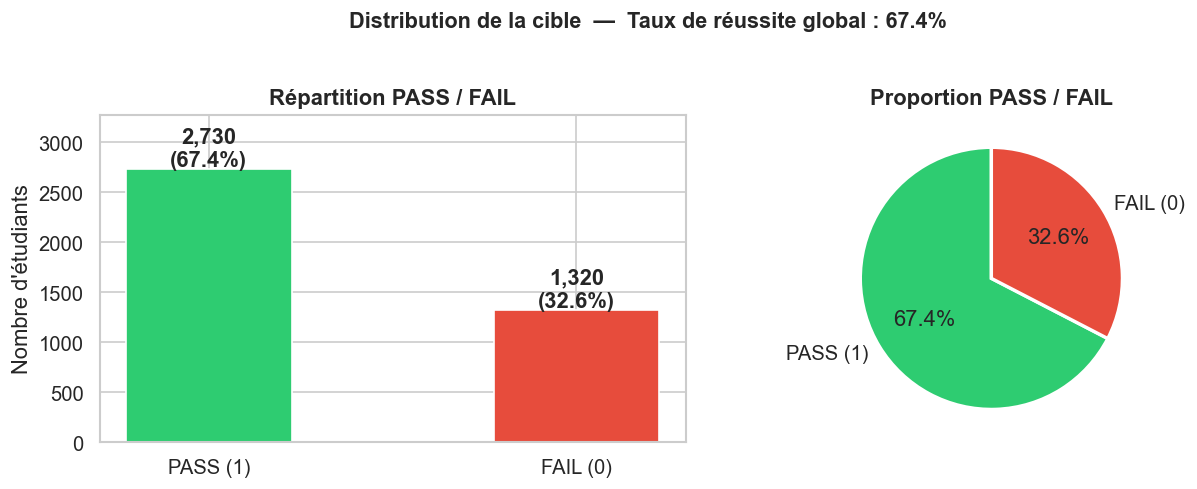


Ratio déséquilibre (PASS/FAIL) : 2.07x
→ Justifie l'usage de class_weight='balanced' dans le modèle.


In [6]:
counts = df['pass'].value_counts()
labels = ['PASS (1)', 'FAIL (0)']
sizes  = [counts[1], counts[0]]
ratio  = counts[1] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barplot
bars = axes[0].bar(labels, sizes, color=[COLORS['PASS'], COLORS['FAIL']], width=0.45, edgecolor='white')
for bar, val in zip(bars, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Répartition PASS / FAIL', fontweight='bold')
axes[0].set_ylabel('Nombre d\'étudiants')
axes[0].set_ylim(0, max(sizes) * 1.2)

# Pie
axes[1].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=[COLORS['PASS'], COLORS['FAIL']],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion PASS / FAIL', fontweight='bold')

plt.suptitle(f'Distribution de la cible  —  Taux de réussite global : {ratio:.1f}%',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nRatio déséquilibre (PASS/FAIL) : {counts[1]/counts[0]:.2f}x")
print("→ Justifie l'usage de class_weight='balanced' dans le modèle.")

## 3. Features comportementales (critères IA)

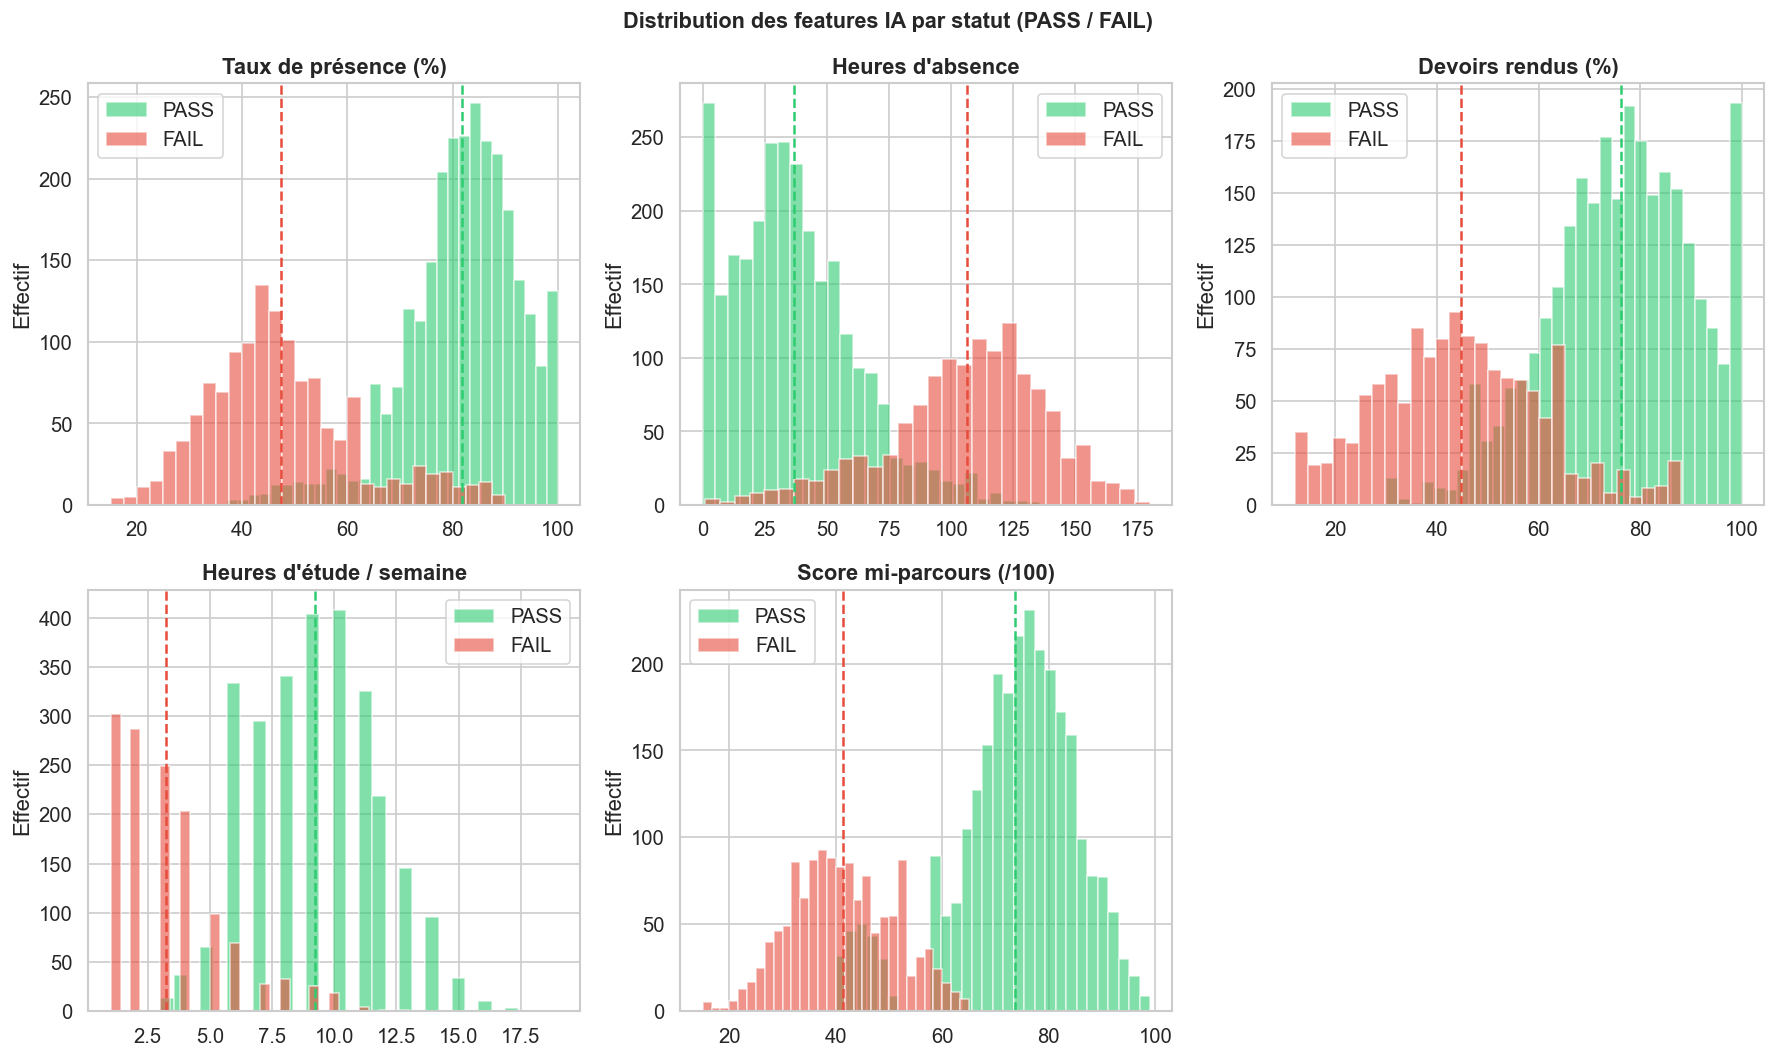

In [7]:
CRITERES_IA = ['attendance_pct', 'absence_hours', 'homework_pct',
                'study_hours_per_week', 'midterm_score']

LABELS = {
    'attendance_pct':       'Taux de présence (%)',
    'absence_hours':        'Heures d\'absence',
    'homework_pct':         'Devoirs rendus (%)',
    'study_hours_per_week': 'Heures d\'étude / semaine',
    'midterm_score':        'Score mi-parcours (/100)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(CRITERES_IA):
    ax = axes[i]
    for label, val, color in [('PASS', 1, COLORS['PASS']), ('FAIL', 0, COLORS['FAIL'])]:
        subset = df[df['pass'] == val][col]
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(LABELS[col], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Effectif')
    ax.legend()

axes[-1].set_visible(False)
plt.suptitle('Distribution des features IA par statut (PASS / FAIL)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

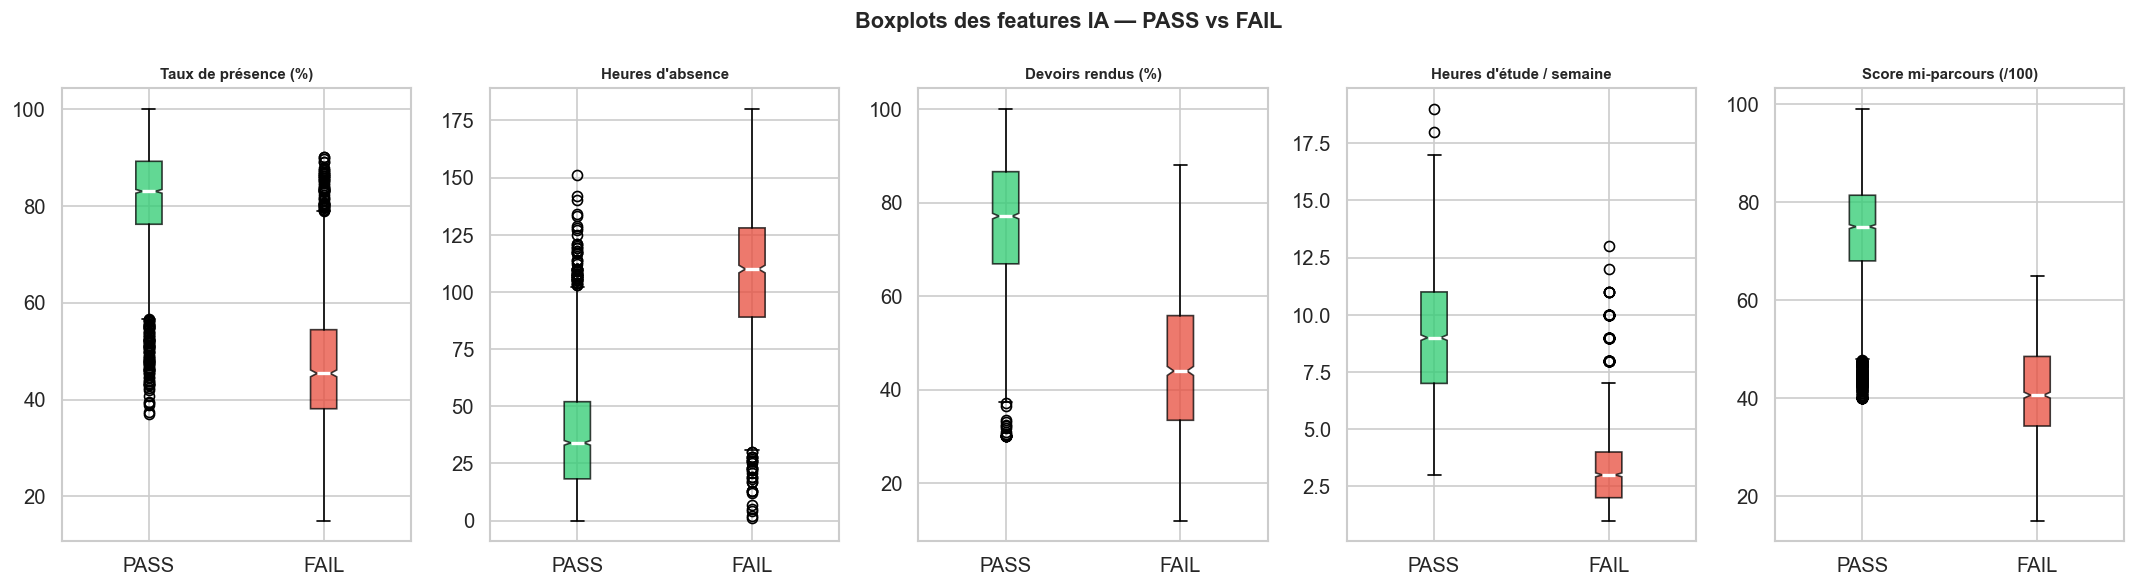

In [8]:
# Boxplots — séparation PASS vs FAIL
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col in zip(axes, CRITERES_IA):
    data_plot = [df[df['pass']==1][col], df[df['pass']==0][col]]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=True,
                    medianprops={'color': 'white', 'linewidth': 2})
    for patch, color in zip(bp['boxes'], [COLORS['PASS'], COLORS['FAIL']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(['PASS', 'FAIL'])
    ax.set_title(LABELS[col], fontweight='bold', fontsize=9)

plt.suptitle('Boxplots des features IA — PASS vs FAIL', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Tests de Student (H0 : les moyennes sont égales entre PASS et FAIL)
print(f"{'Feature':<28} {'Moy PASS':>10} {'Moy FAIL':>10} {'p-value':>12} {'Significatif':>14}")
print('-' * 80)
for col in CRITERES_IA:
    g1 = df[df['pass']==1][col]
    g0 = df[df['pass']==0][col]
    _, p = stats.ttest_ind(g1, g0)
    sig = '✅ Oui' if p < 0.05 else '❌ Non'
    print(f"{col:<28} {g1.mean():>10.2f} {g0.mean():>10.2f} {p:>12.2e} {sig:>14}")

Feature                        Moy PASS   Moy FAIL      p-value   Significatif
--------------------------------------------------------------------------------
attendance_pct                    81.83      47.35     0.00e+00          ✅ Oui
absence_hours                     36.82     106.28     0.00e+00          ✅ Oui
homework_pct                      76.13      44.78     0.00e+00          ✅ Oui
study_hours_per_week               9.23       3.25     0.00e+00          ✅ Oui
midterm_score                     73.63      41.34     0.00e+00          ✅ Oui


## 4. Notes par matière

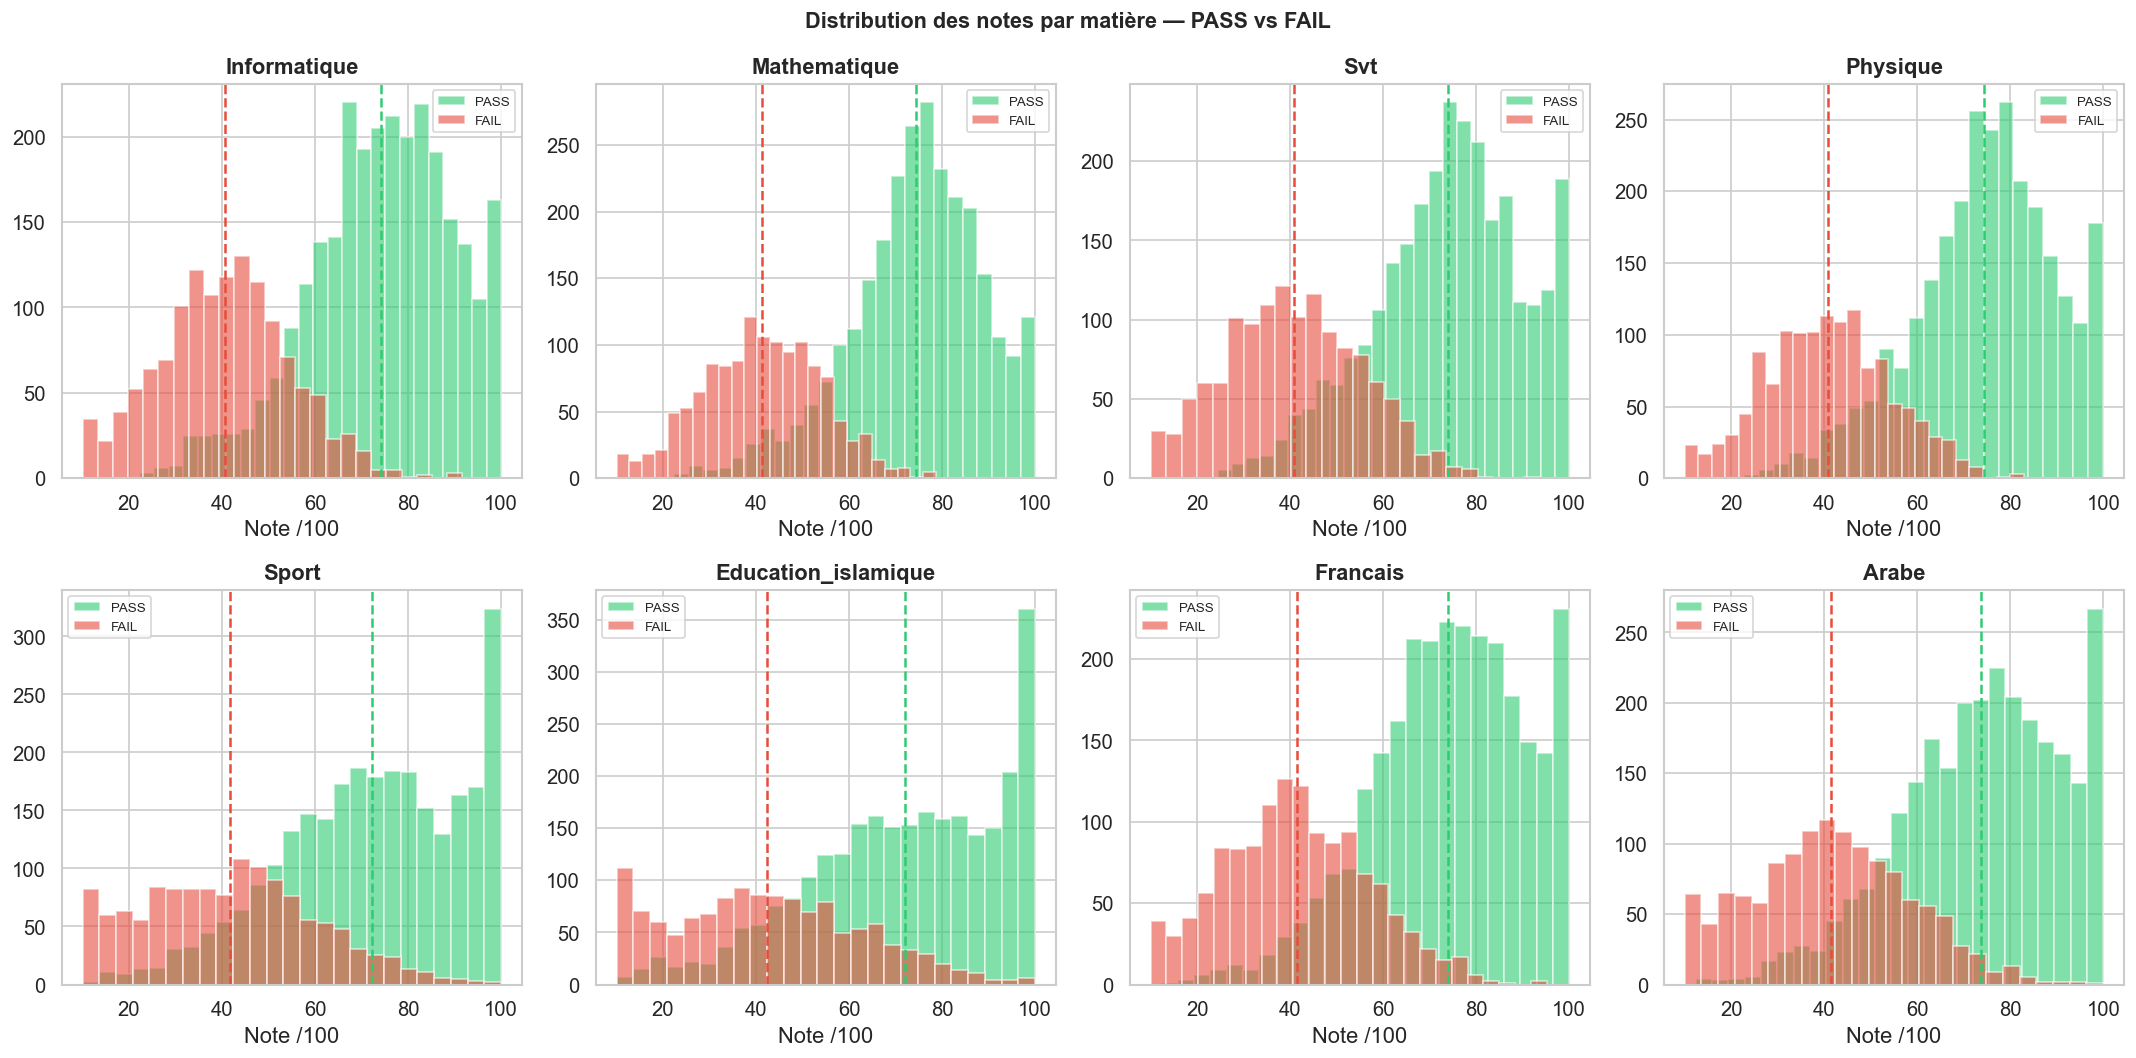

In [10]:
MATIERES = ['informatique', 'mathematique', 'svt', 'physique',
            'sport', 'education_islamique', 'francais', 'arabe']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(MATIERES):
    ax = axes[i]
    for label, val, color in [('PASS', 1, COLORS['PASS']), ('FAIL', 0, COLORS['FAIL'])]:
        subset = df[df['pass'] == val][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
        ax.axvline(subset.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_title(col.capitalize(), fontweight='bold')
    ax.set_xlabel('Note /100')
    ax.legend(fontsize=8)

plt.suptitle('Distribution des notes par matière — PASS vs FAIL',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

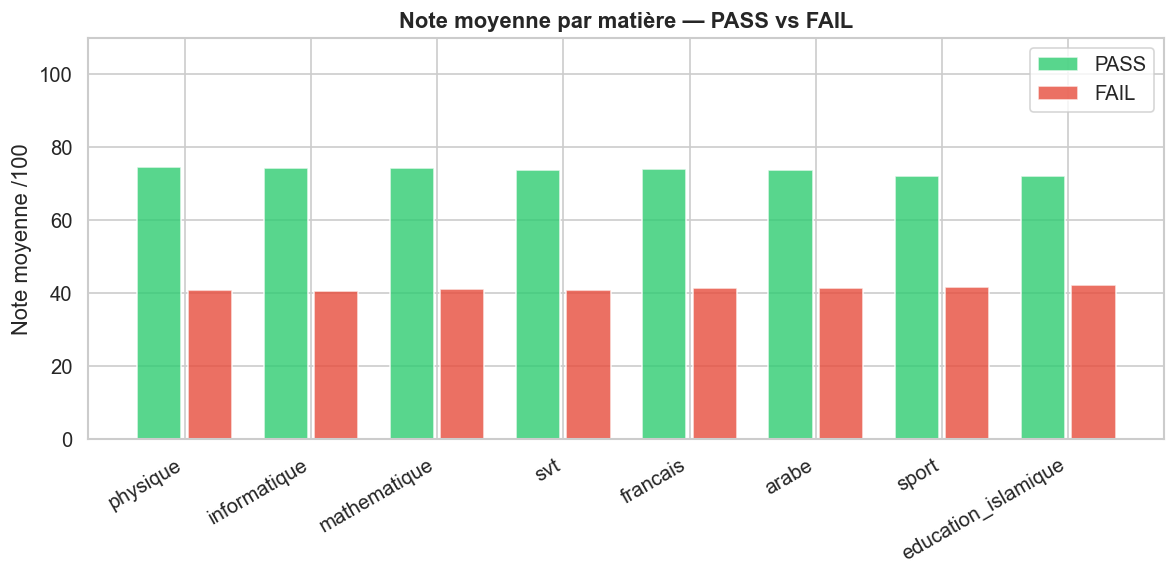


Écart de moyenne (PASS - FAIL) par matière :
                      PASS   FAIL  Écart
physique             74.45  40.83  33.62
informatique         74.22  40.66  33.56
mathematique         74.34  41.28  33.06
svt                  73.86  40.80  33.06
francais             74.05  41.46  32.59
arabe                73.82  41.54  32.28
sport                72.24  41.82  30.42
education_islamique  72.04  42.35  29.69


In [11]:
# Moyennes par matière selon le statut
mean_by_status = df.groupby('pass')[MATIERES].mean().T
mean_by_status.columns = ['FAIL', 'PASS']
mean_by_status['Écart'] = mean_by_status['PASS'] - mean_by_status['FAIL']
mean_by_status = mean_by_status.sort_values('Écart', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(mean_by_status))
ax.bar([i - 0.2 for i in x], mean_by_status['PASS'], 0.35,
       color=COLORS['PASS'], alpha=0.8, label='PASS')
ax.bar([i + 0.2 for i in x], mean_by_status['FAIL'], 0.35,
       color=COLORS['FAIL'], alpha=0.8, label='FAIL')
ax.set_xticks(list(x))
ax.set_xticklabels(mean_by_status.index, rotation=30, ha='right')
ax.set_ylabel('Note moyenne /100')
ax.set_title('Note moyenne par matière — PASS vs FAIL', fontweight='bold')
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

print("\nÉcart de moyenne (PASS - FAIL) par matière :")
print(mean_by_status[['PASS','FAIL','Écart']].round(2).to_string())

## 5. Corrélations

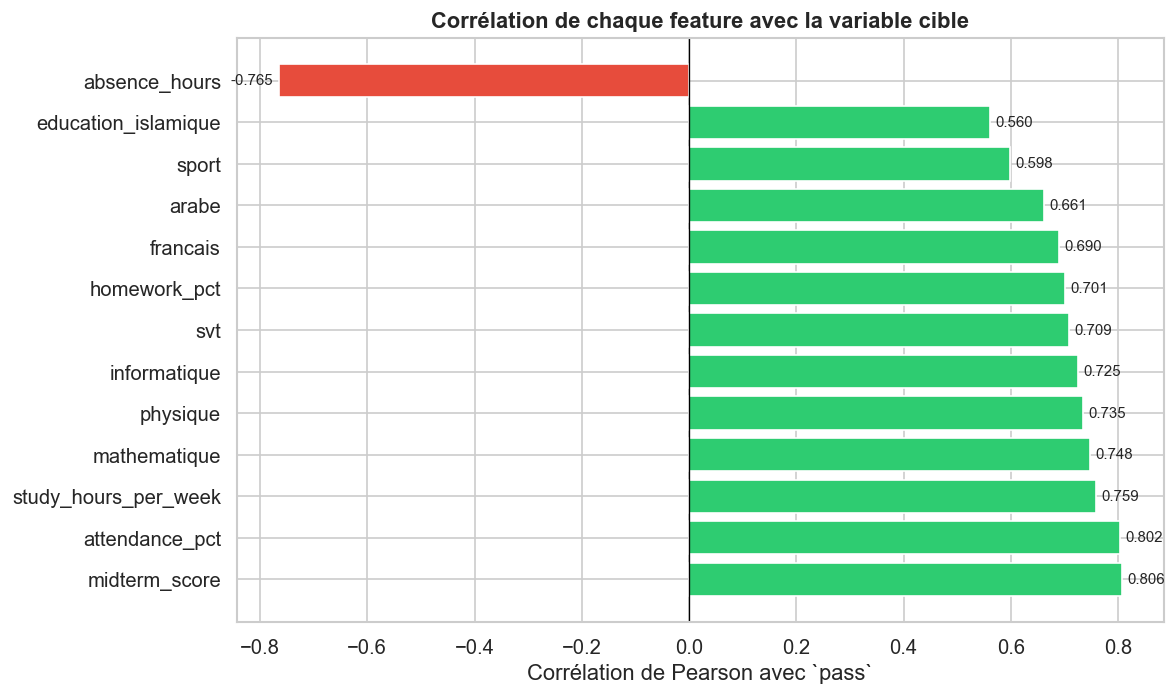

In [12]:
# Corrélation de chaque feature avec `pass`
corr_pass = df.drop(columns='student_id').corr()['pass'].drop('pass').sort_values(ascending=False)

colors_bar = [COLORS['PASS'] if v > 0 else COLORS['FAIL'] for v in corr_pass]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(corr_pass.index, corr_pass.values, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, corr_pass.values):
    ax.text(val + (0.01 if val >= 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Corrélation de Pearson avec `pass`')
ax.set_title('Corrélation de chaque feature avec la variable cible', fontweight='bold')
plt.tight_layout()
plt.show()

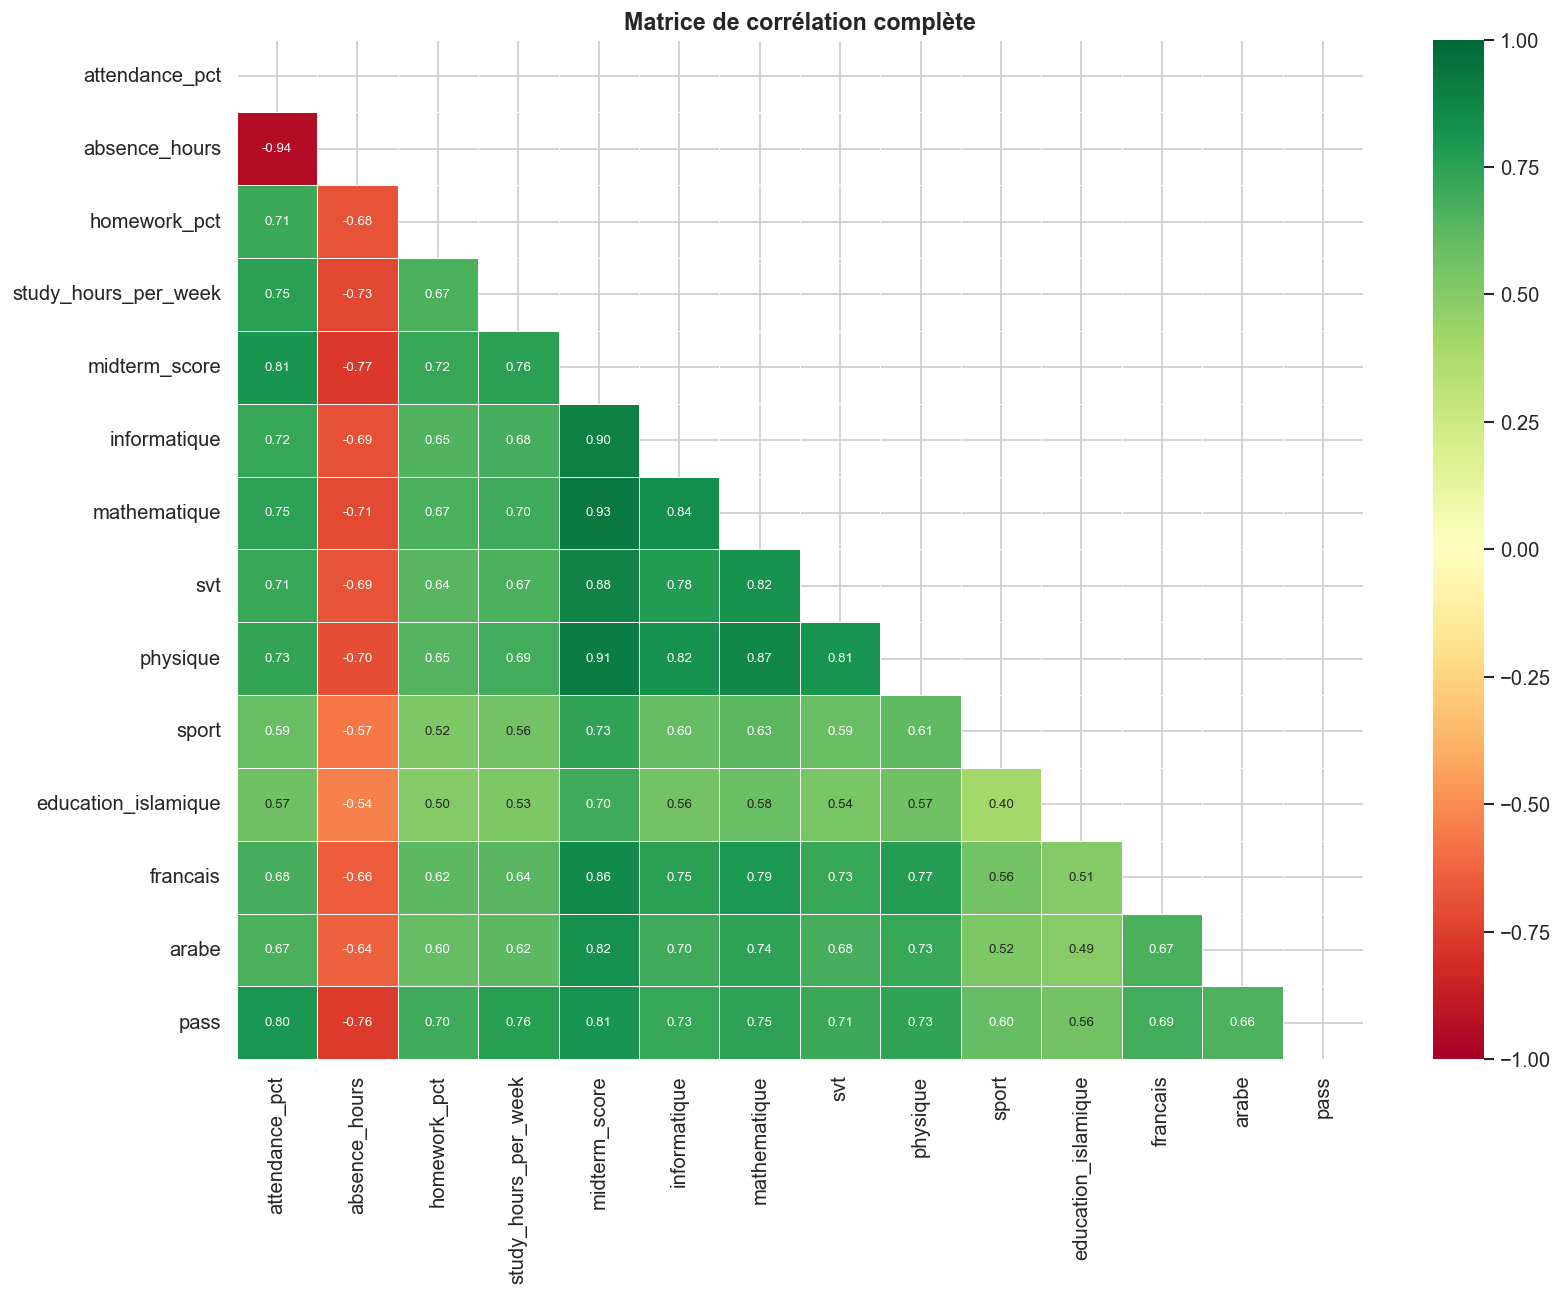

In [13]:
# Heatmap complète
fig, ax = plt.subplots(figsize=(14, 11))
corr_matrix = df.drop(columns='student_id').corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Matrice de corrélation complète', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Analyse des seuils critiques (règles métier)

In [14]:
# Taux de réussite selon les seuils utilisés dans api.py
seuils = [
    ('absence_hours > 20',        df['absence_hours'] > 20),
    ('attendance_pct < 75',       df['attendance_pct'] < 75),
    ('homework_pct < 65',         df['homework_pct'] < 65),
    ('study_hours_per_week < 6',  df['study_hours_per_week'] < 6),
    ('midterm_score < 60',        df['midterm_score'] < 60),
]

print(f"{'Condition':<35} {'N étudiants':>12} {'Taux FAIL':>12} {'Taux PASS':>12}")
print('-' * 75)
for label, mask in seuils:
    sub = df[mask]
    n = len(sub)
    fail_rate = (sub['pass'] == 0).mean() * 100
    pass_rate = (sub['pass'] == 1).mean() * 100
    print(f"{label:<35} {n:>12,} {fail_rate:>11.1f}% {pass_rate:>11.1f}%")

Condition                            N étudiants    Taux FAIL    Taux PASS
---------------------------------------------------------------------------
absence_hours > 20                         3,283        39.8%        60.2%
attendance_pct < 75                        1,833        67.5%        32.5%
homework_pct < 65                          1,777        67.9%        32.1%
study_hours_per_week < 6                   1,255        90.8%         9.2%
midterm_score < 60                         1,590        80.9%        19.1%


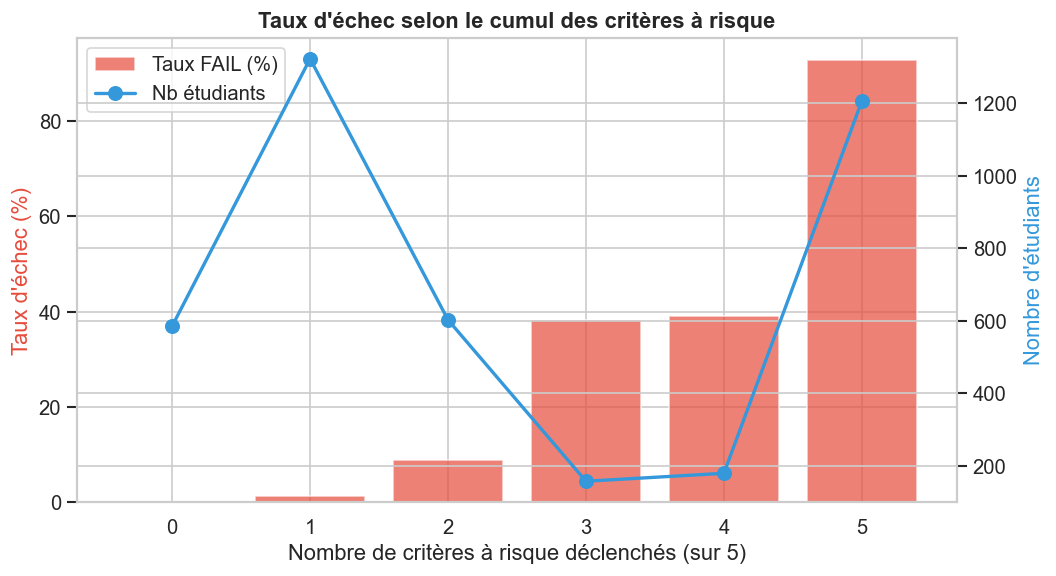

In [15]:
# Visualisation : taux d'échec selon le nombre de critères à risque déclenchés
df_risk = df.copy()
df_risk['risk_count'] = (
    (df_risk['absence_hours'] > 20).astype(int) +
    (df_risk['attendance_pct'] < 75).astype(int) +
    (df_risk['homework_pct'] < 65).astype(int) +
    (df_risk['study_hours_per_week'] < 6).astype(int) +
    (df_risk['midterm_score'] < 60).astype(int)
)

fail_by_risk = df_risk.groupby('risk_count')['pass'].apply(lambda x: (x==0).mean() * 100)
counts_by_risk = df_risk['risk_count'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar(fail_by_risk.index, fail_by_risk.values, color=COLORS['FAIL'], alpha=0.7, label='Taux FAIL (%)')
ax2.plot(counts_by_risk.index, counts_by_risk.values, 'o-', color=COLORS['neutral'],
         linewidth=2, markersize=8, label='Nb étudiants')

ax1.set_xlabel('Nombre de critères à risque déclenchés (sur 5)')
ax1.set_ylabel('Taux d\'échec (%)', color=COLORS['FAIL'])
ax2.set_ylabel('Nombre d\'étudiants', color=COLORS['neutral'])
ax1.set_title('Taux d\'échec selon le cumul des critères à risque', fontweight='bold')
ax1.set_xticks(range(6))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

## 7. Relations bivariées clés

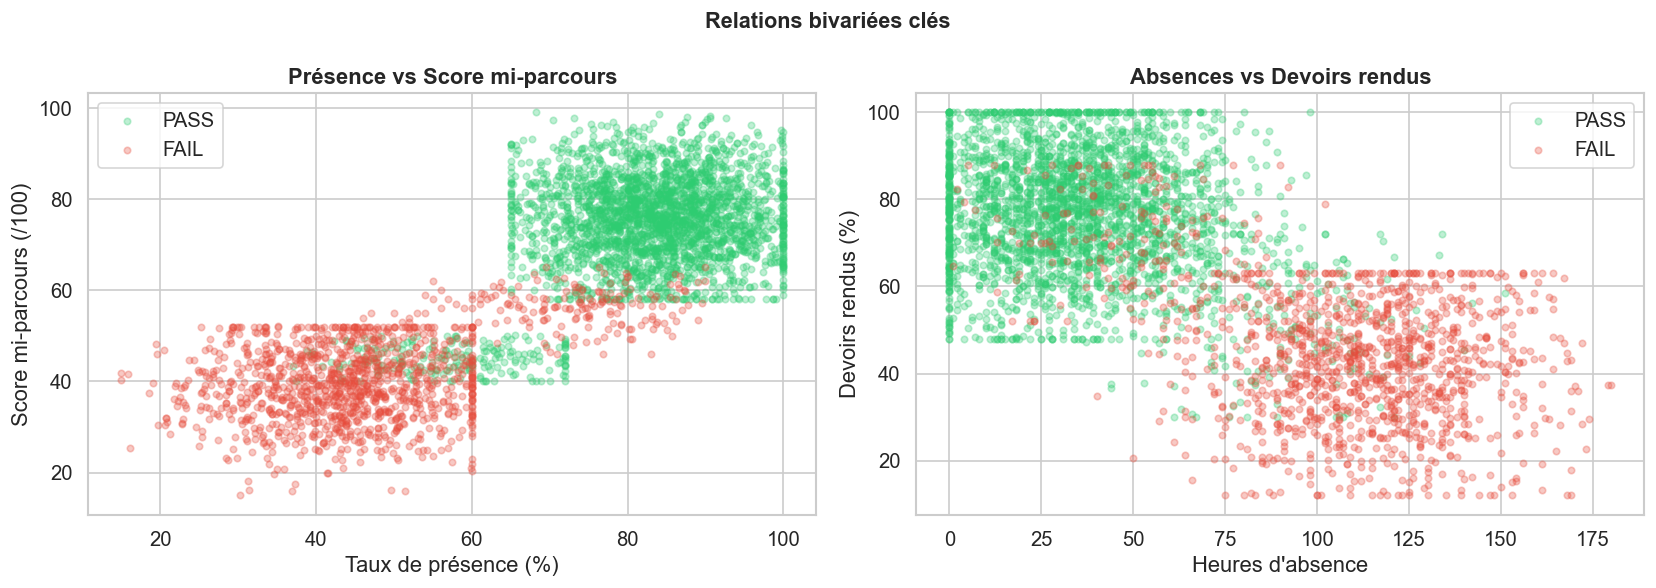

In [16]:
# Scatter : attendance vs midterm_score, coloré par pass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for val, label, color in [(1, 'PASS', COLORS['PASS']), (0, 'FAIL', COLORS['FAIL'])]:
    sub = df[df['pass'] == val]
    axes[0].scatter(sub['attendance_pct'], sub['midterm_score'],
                    alpha=0.3, s=15, color=color, label=label)
axes[0].set_xlabel('Taux de présence (%)')
axes[0].set_ylabel('Score mi-parcours (/100)')
axes[0].set_title('Présence vs Score mi-parcours', fontweight='bold')
axes[0].legend()

for val, label, color in [(1, 'PASS', COLORS['PASS']), (0, 'FAIL', COLORS['FAIL'])]:
    sub = df[df['pass'] == val]
    axes[1].scatter(sub['absence_hours'], sub['homework_pct'],
                    alpha=0.3, s=15, color=color, label=label)
axes[1].set_xlabel('Heures d\'absence')
axes[1].set_ylabel('Devoirs rendus (%)')
axes[1].set_title('Absences vs Devoirs rendus', fontweight='bold')
axes[1].legend()

plt.suptitle('Relations bivariées clés', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()